# Phân cụm khách hàng (Customer Clustering) và Chuẩn bị dữ liệu Causal ML

Phân cụm khách hàng nhằm mục đích nhận diện các nhóm hành vi mua sắm khác nhau của các hộ gia đình (households). Kết quả phân cụm không chỉ giúp hiểu rõ đặc điểm khách hàng mà còn đóng vai trò là các biến quan sát (covariates/features) quan trọng trong mô hình Causal Machine Learning để đánh giá tác động của các chiến dịch khuyến mãi (Campaign Type A, B & C).

Tài liệu này bao gồm toàn bộ quá trình:
1. Đọc và chuẩn hóa dữ liệu.
2. Tính toán RFM & Nhân khẩu học.
3. K-Means Clustering (Elbow & Silhouette).
4. Phác họa đặc điểm các cụm (Profiling) & Trực quan hóa.
5. Xuất dữ liệu đã gán nhãn cho mô hình Causal ML.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.ticker as ticker
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Cấu hình matplotlib hiển thị trực tiếp trong notebook
%matplotlib inline

## 1. Đọc và Xử lý dữ liệu ban đầu
Tính toán RFM từ `transaction_data.csv` và ghép nối với `hh_demographic.csv`.

**Các Đặc Trưng (Features) Phân Cụm:**
Mô hình kết hợp các chỉ số hành vi RFM và thông tin nhân khẩu học:
1.  **Recency (R):** Số ngày kể từ lần mua sắm cuối cùng đến thời điểm hiện tại. (Khách hàng càng lâu không mua thì R càng cao).
2.  **Frequency (F):** Tổng số lượng giỏ hàng (Basket) duy nhất.
3.  **Monetary (M):** Tổng giá trị mua sắm (`SALES_VALUE`).
4.  **Income Level:** Mức thu nhập, được mã hóa thứ bậc (Ordinal Encoding) từ 1 (Dưới 15K) đến 12 (Trên 250K+).
5.  **Age Level:** Nhóm tuổi, được mã hóa thứ bậc từ 1 (19-24) đến 6 (65+).
6.  **Household Size:** Số lượng thành viên trong gia đình (Từ 1 đến 5+).

In [10]:
print("Đọc dữ liệu...")
trans_df = pd.read_csv("data/transaction_data.csv")
demo_df = pd.read_csv("data/hh_demographic.csv")
camp_df = pd.read_csv("data/campaign_desc.csv")

# 1. Xác định T_start (Xét toàn bộ Type A, B, C)
t_start = camp_df['START_DAY'].min()
print(f"Ngày bắt đầu chiến dịch đầu tiên (toàn bộ Type A, B, C) (T_start) = {t_start}")

# 2. Lọc dữ liệu giao dịch TRƯỚC chiến dịch
pre_trans = trans_df[trans_df['DAY'] < t_start].copy()
print(f"Số lượng giao dịch trước chiến dịch: {len(pre_trans)}")

# 3. Tính toán các đặc trưng (RFM & Coupon Usage)
rfm = pre_trans.groupby('household_key').agg(
    Recency=('DAY', lambda x: t_start - x.max()),
    Frequency=('BASKET_ID', 'nunique'),
    Monetary=('SALES_VALUE', 'sum'),
    Coupon_Usage=('COUPON_DISC', lambda x: (x < 0).sum())
).reset_index()

# 4. Gộp Demographic
demo_df.columns = ['Age_Desc', 'Marital_Status', 'Income_Desc', 'Homeowner_Desc', 'HH_Comp_Desc', 'Household_Size_Desc', 'Kid_Category_Desc', 'household_key']

# Merge
merged_df = pd.merge(rfm, demo_df, on='household_key', how='inner')

# Mã hóa trực tiếp từ dữ liệu ẩn danh (vd: 'Level4' -> 4, 'Age Group6' -> 6)
merged_df['Income_Level'] = merged_df['Income_Desc'].str.extract(r'(\d+)').astype(float)
merged_df['Household_Size'] = merged_df['Household_Size_Desc'].astype(str).str.extract(r'(\d+)').astype(float).fillna(1)
merged_df['Age_Level'] = merged_df['Age_Desc'].str.extract(r'(\d+)').astype(float)

features_cols = ['Recency', 'Frequency', 'Monetary', 'Coupon_Usage', 'Income_Level', 'Age_Level', 'Household_Size']
features = merged_df[features_cols].dropna()
final_df = merged_df.loc[features.index].copy()

print(f"Số lượng khách hàng đủ dữ kiện phân tích (trước chiến dịch): {len(features)}")

Đọc dữ liệu...
Ngày bắt đầu chiến dịch đầu tiên (toàn bộ Type A, B, C) (T_start) = 224
Số lượng giao dịch trước chiến dịch: 627727
Số lượng khách hàng đủ dữ kiện phân tích (trước chiến dịch): 801


## 2. Tìm K tối ưu bằng Elbow & Silhouette

*   **Chuẩn hóa dữ liệu:** Áp dụng `StandardScaler` để đưa các đặc trưng về cùng một thang đo, tránh việc các biến có giá trị lớn (như Monetary) áp đảo các biến khác.
*   **Lựa chọn số lượng cụm (K):** Kết hợp phương pháp **Elbow Method** (đánh giá WCSS - Within-Cluster Sum of Square) và **Silhouette Score** với tập giá trị K chạy từ 2 đến 10. Số lượng cụm tối ưu được chọn tại điểm có Silhouette Score cao nhất.

Tính toán Elbow và Silhouette...


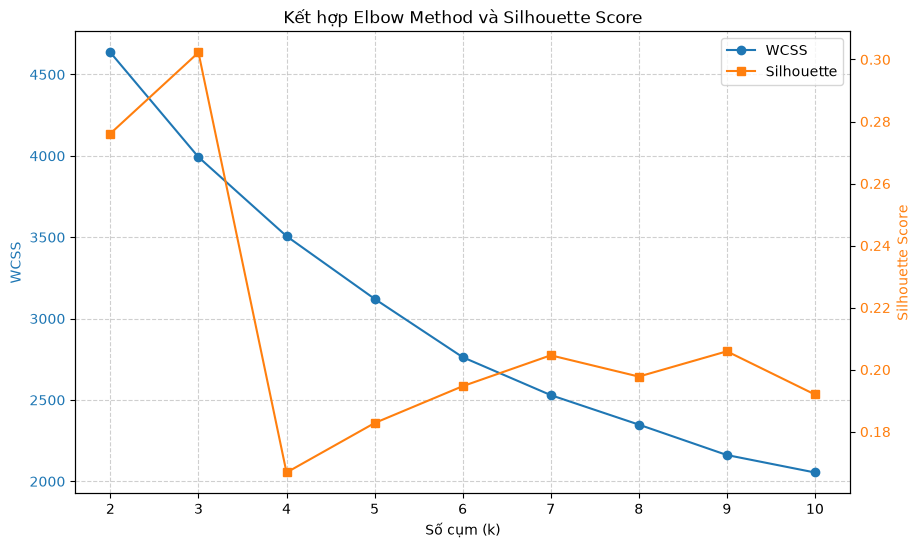

Số cụm tối ưu được chọn: k = 3


In [11]:
# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

wcss = []
silhouette_scores = []
K_range = range(2, 11)

print("Tính toán Elbow và Silhouette...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

# Trực quan hóa
fig, ax1 = plt.subplots(figsize=(10, 6))
color1 = 'tab:blue'
ax1.set_xlabel('Số cụm (k)')
ax1.set_ylabel('WCSS', color=color1)
line1 = ax1.plot(K_range, wcss, marker='o', linestyle='-', color=color1, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(K_range)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()  
color2 = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color2)
line2 = ax2.plot(K_range, silhouette_scores, marker='s', linestyle='-', color=color2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
plt.title('Kết hợp Elbow Method và Silhouette Score')
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f"Số cụm tối ưu được chọn: k = {best_k}")


## 3. Thực hiện K-Means & Profiling


In [12]:
# Chạy K-Means với K tốt nhất
kmeans_opt = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_df['Cluster'] = kmeans_opt.fit_predict(X_scaled)

# Tính toán kích thước mỗi cụm
cluster_sizes = final_df['Cluster'].value_counts().sort_index()
cluster_props = (final_df['Cluster'].value_counts(normalize=True).sort_index() * 100).round(2)
size_df = pd.DataFrame({'Số lượng': cluster_sizes, 'Tỷ lệ (%)': cluster_props})

# Tính toán đặc điểm trung bình
profile = final_df.groupby('Cluster')[features_cols].mean().round(2)

# Gộp thành 1 bảng duy nhất
combined_profile = pd.concat([size_df, profile], axis=1)

print("--- Tổng hợp Kích thước và Đặc điểm trung bình của mỗi cụm ---")
display(combined_profile)

--- Tổng hợp Kích thước và Đặc điểm trung bình của mỗi cụm ---


,Số lượng,Tỷ lệ (%),Recency,Frequency,Monetary,Coupon_Usage,Income_Level,Age_Level,Household_Size
Cluster,,,,,,,,,
0,599,74.78,6.59,29.79,872.37,2.82,4.46,3.51,2.11
1,22,2.75,131.05,3.91,132.19,0.18,4.95,3.77,2.18
2,180,22.47,3.51,80.42,2664.67,16.85,5.51,3.38,2.48


## Trực quan hóa RFM 3D (3D Plot)
Biểu đồ 3D thể hiện sự phân bổ của khách hàng theo 3 trục Recency, Frequency, và Monetary.

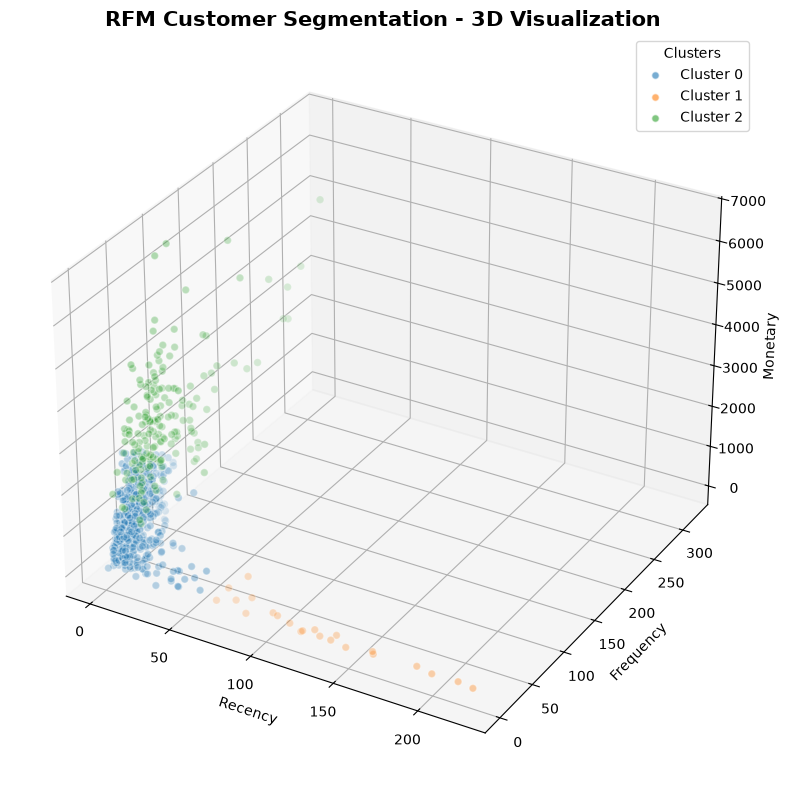

In [13]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

xs = final_df['Recency']
ys = final_df['Frequency']
zs = final_df['Monetary']
clusters_ids = final_df['Cluster']

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

for i in sorted(clusters_ids.unique()):
    ax.scatter(
        xs[clusters_ids == i], 
        ys[clusters_ids == i], 
        zs[clusters_ids == i], 
        c=colors[i % len(colors)], 
        s=30, 
        label=f'Cluster {i}', 
        alpha=0.6,
        edgecolor='w'
    )

ax.set_title('RFM Customer Segmentation - 3D Visualization', fontsize=15, fontweight='bold')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.legend(title="Clusters")

plt.tight_layout()
plt.show()

## 4. Trực quan hoá sự phân tách (PCA)


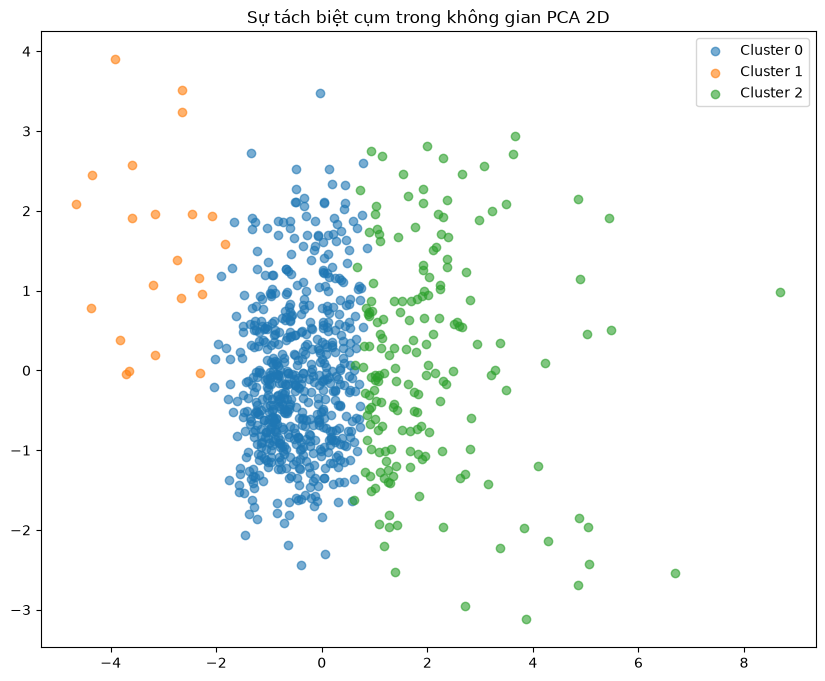

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
final_df['PCA1'] = X_pca[:, 0]
final_df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
clusters = sorted(final_df['Cluster'].unique())
for c in clusters:
    subset = final_df[final_df['Cluster'] == c]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {c}', alpha=0.6)
plt.legend()
plt.title('Sự tách biệt cụm trong không gian PCA 2D')
plt.show()


## 5. Đặt tên Cụm & Vẽ Boxplots

Dựa trên giá trị trung bình của từng cụm so với trung bình của toàn bộ tập khách hàng, các cụm được gán nhãn tự động theo logic kinh doanh (Business Logic) gồm 3 nhóm chính:
*   **High-Value Loyal:** Nếu mức chi tiêu (Monetary) > 1.5 lần mức trung bình toàn tập (khách hàng VIP).
*   **Churned/At-Risk:** Nếu thời gian bỏ lại (Recency) > 1.5 lần mức trung bình (khách hàng có nguy cơ rời bỏ).
*   **Standard Customers:** Khách hàng thông thường, không vi phạm 2 ngưỡng trên.

*(Ghi chú: Nếu cụm có mức thu nhập (Income Level) cao hơn trung bình, cụm sẽ được gắn thêm hậu tố "(High Income)").*

Tên các cụm đã gán:
Cluster 0: Standard Customers
Cluster 1: Churned/At-Risk (High Income)
Cluster 2: High-Value Loyal (High Income)


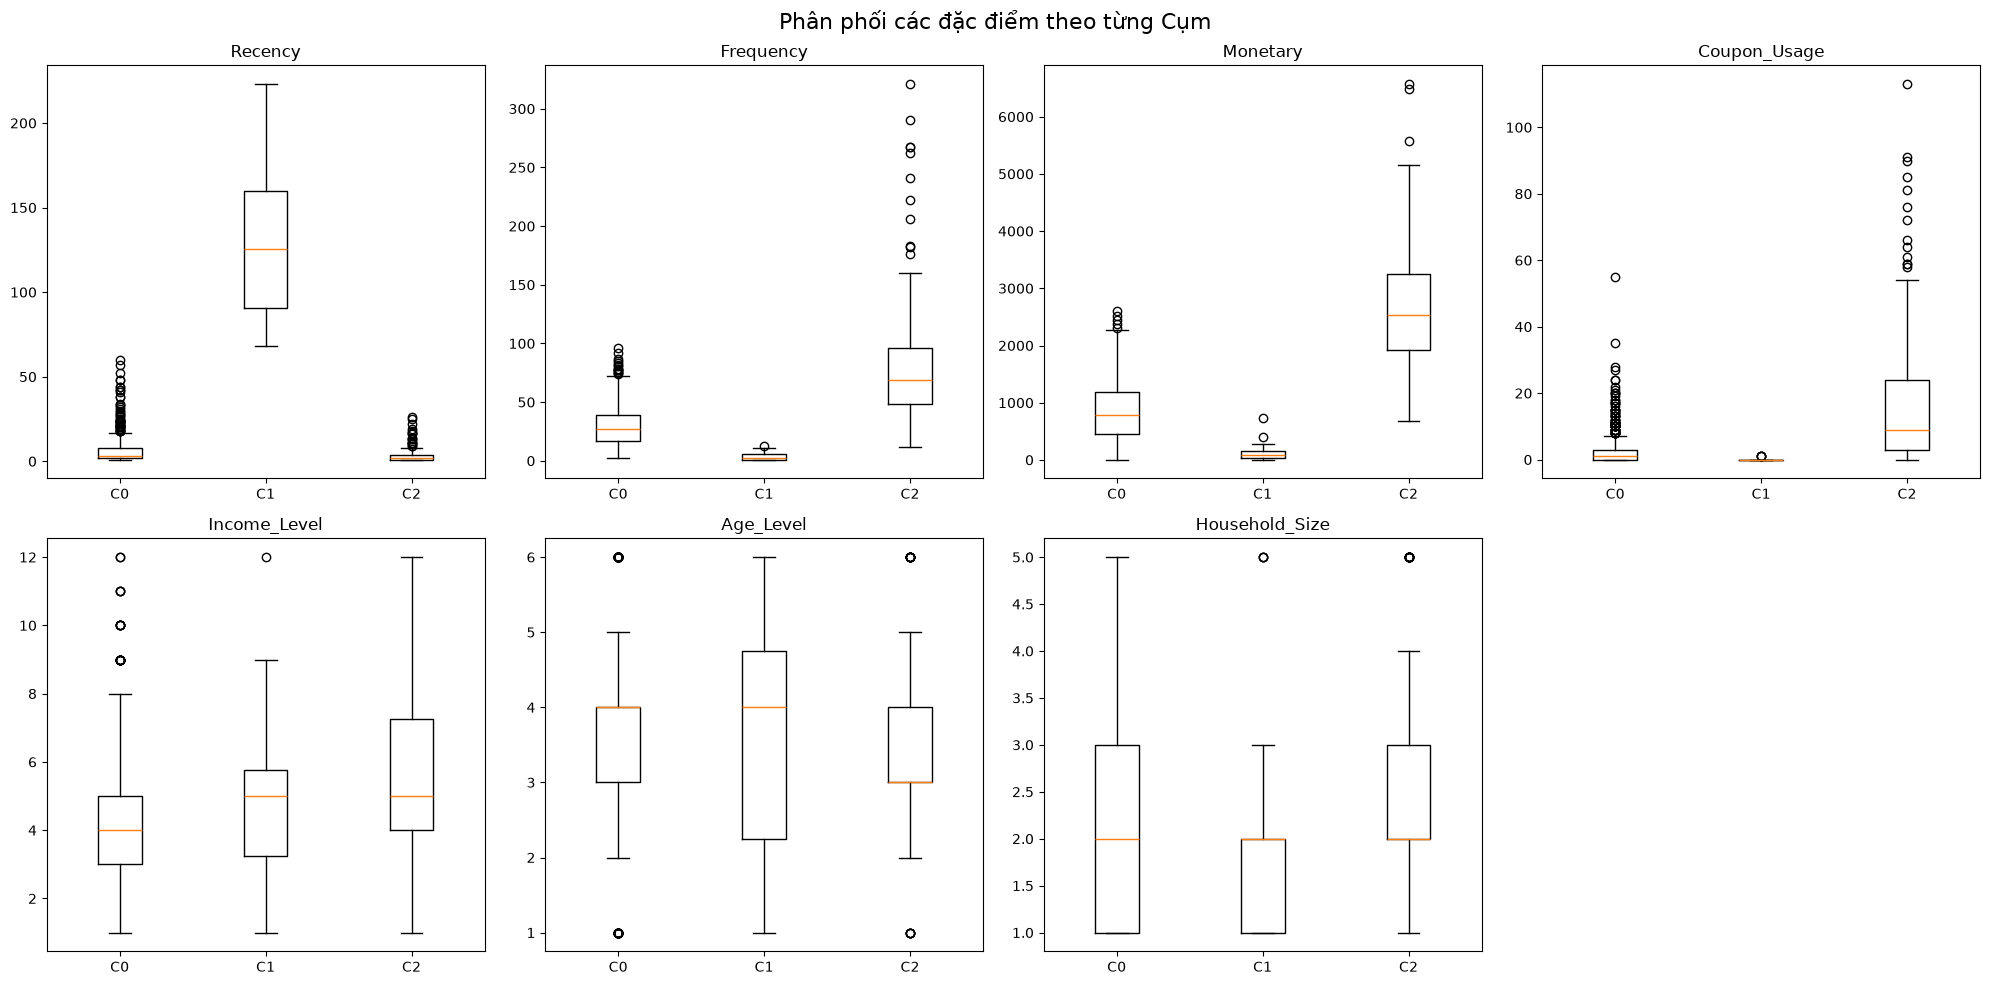

In [15]:
# Naming
cluster_names = {}
overall_monetary_mean = final_df['Monetary'].mean()
overall_recency_mean = final_df['Recency'].mean()

for cluster_id, row in profile.iterrows():
    if row['Monetary'] > overall_monetary_mean * 1.5:
        name = "High-Value Loyal"
    elif row['Recency'] > overall_recency_mean * 1.5:
        name = "Churned/At-Risk"
    else:
        name = "Standard Customers"
    
    if row['Income_Level'] > final_df['Income_Level'].mean():
        name += " (High Income)"
    
    cluster_names[cluster_id] = f"Cluster {cluster_id}: {name}"

final_df['Cluster_Name'] = final_df['Cluster'].map(lambda x: cluster_names[x].split(': ')[1])
print("Tên các cụm đã gán:")
for k, v in cluster_names.items():
    print(v)

# Boxplots
clusters_unique = sorted(final_df['Cluster'].unique())
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
fig.suptitle('Phân phối các đặc điểm theo từng Cụm', fontsize=16)

for i, feature in enumerate(features_cols):
    ax = axes[i]
    grouped_data = [final_df[final_df['Cluster'] == c][feature] for c in clusters_unique]
    ax.boxplot(grouped_data)
    ax.set_xticks(range(1, len(clusters_unique) + 1))
    ax.set_xticklabels([f"C{c}" for c in clusters_unique])
    ax.set_title(feature)

# Ẩn các ô biểu đồ thừa
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6. Xuất Dữ liệu cho Causal ML

Kết quả của cụm được One-hot Encoding (biến đổi thành các cột dummy) và hợp nhất với tập dữ liệu gốc, xuất ra file `causal_ml_ready_data.csv`. File này hoàn toàn sẵn sàng cho các bước ước lượng tác động nhân quả (ATE, CATE)

In [16]:
causal_df = pd.get_dummies(final_df, columns=['Cluster_Name'], drop_first=False)

output_file = "data/causal_ml_ready_data.csv"
causal_df.to_csv(output_file, index=False)
print(f"Đã lưu dataset cuối cùng vào '{output_file}', sẵn sàng cho mô hình Causal ML.")

Đã lưu dataset cuối cùng vào 'data/causal_ml_ready_data.csv', sẵn sàng cho mô hình Causal ML.
